In [ ]:
import numpy as np
import pandas as pd 
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram 
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
import os
import sys
import cluster
import plots 
import svd
%load_ext autoreload
%autoreload 2

In [2]:
# mutant 
# % open from SAXS
saxs = {
        'E':100, 
        'R':90,
        'Q':84,
        'N':77,
        'V':35,
        'G':32,
        'A':24,
        'S':24,
        }

In [3]:
# would be nice to have a mutant close to 50% activation
# maybe atchley factors can suggest
# find a residue in between N and V


# from eidos.bio import atchley_factors as af
# from eidos.utils import sort_dictionary_values as sort_dict

# midpoint = np.mean([af['N'],af['V']], axis=0)
# resi_similarities = {}
# for res_id, factors in af.items():
#     resi_similarities[res_id] = np.linalg.norm(factors - midpoint)
# sort_dict(resi_similarities) 

In [ ]:
df = pd.read_csv('chespa_cs.csv', index_col='RESI')

In [3]:
# open the combined ccs data for all the states
df = pd.read_csv('test_data.csv', index_col='RESI')

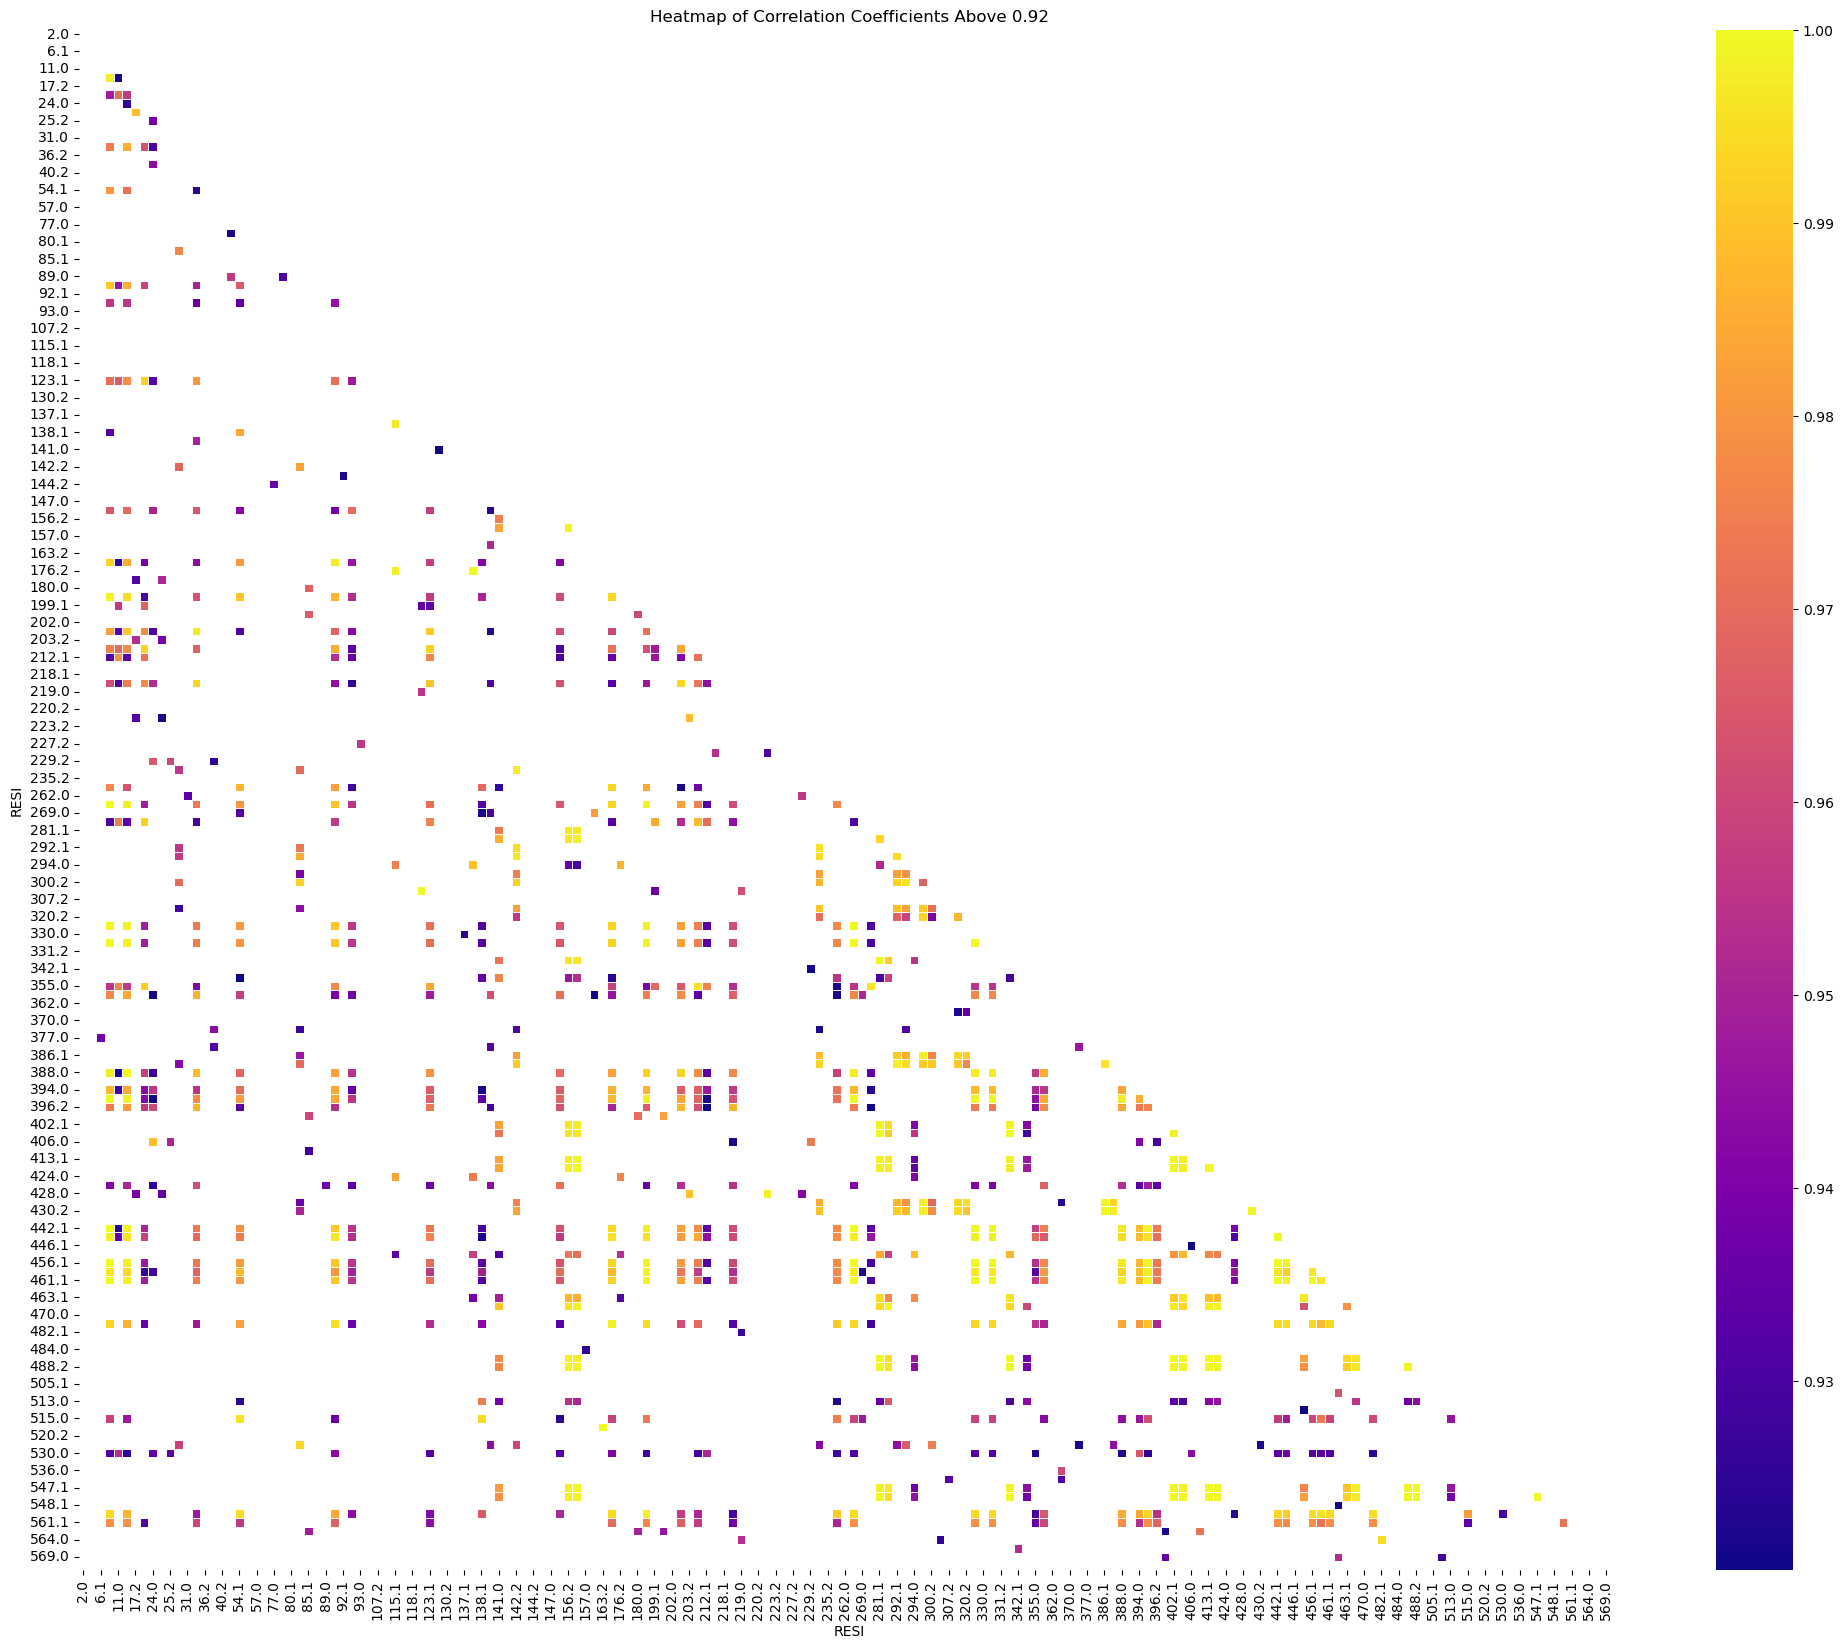

In [4]:
# decide on a cutoff
plots.heatmap_correlation_cutoffs(df, min_corr=.92)

In [306]:
for i, r in enumerate(df.index):
    check = 0
    for s in df.index[i+1:]:
        if r == s:
            print(r)

In [ ]:
absolute_corr = df.corr().abs()
corr_distance = 1 - absolute_corr

In [ ]:

linkage = AgglomerativeClustering(n_clusters=None, 
                                       distance_threshold=.02, 
                                       metric='euclidean', 
                                       linkage='complete')
link = linkage.fit(corr_distance)

In [ ]:
dfc = pd.DataFrame(index=corr_distance.index)


dfc['cluster'] = link.labels_

In [ ]:
# perform clustering on the correlation matrix
hac = cluster.HAC(df,cutoff=96)
# look at the absolute values of the correlation matrix
hac.absolute_corr

Duplicate indices found in the dataframe. Please fix this before proceeding.


ValueError: Duplicate indices found in the dataframe. Please fix this before proceeding.

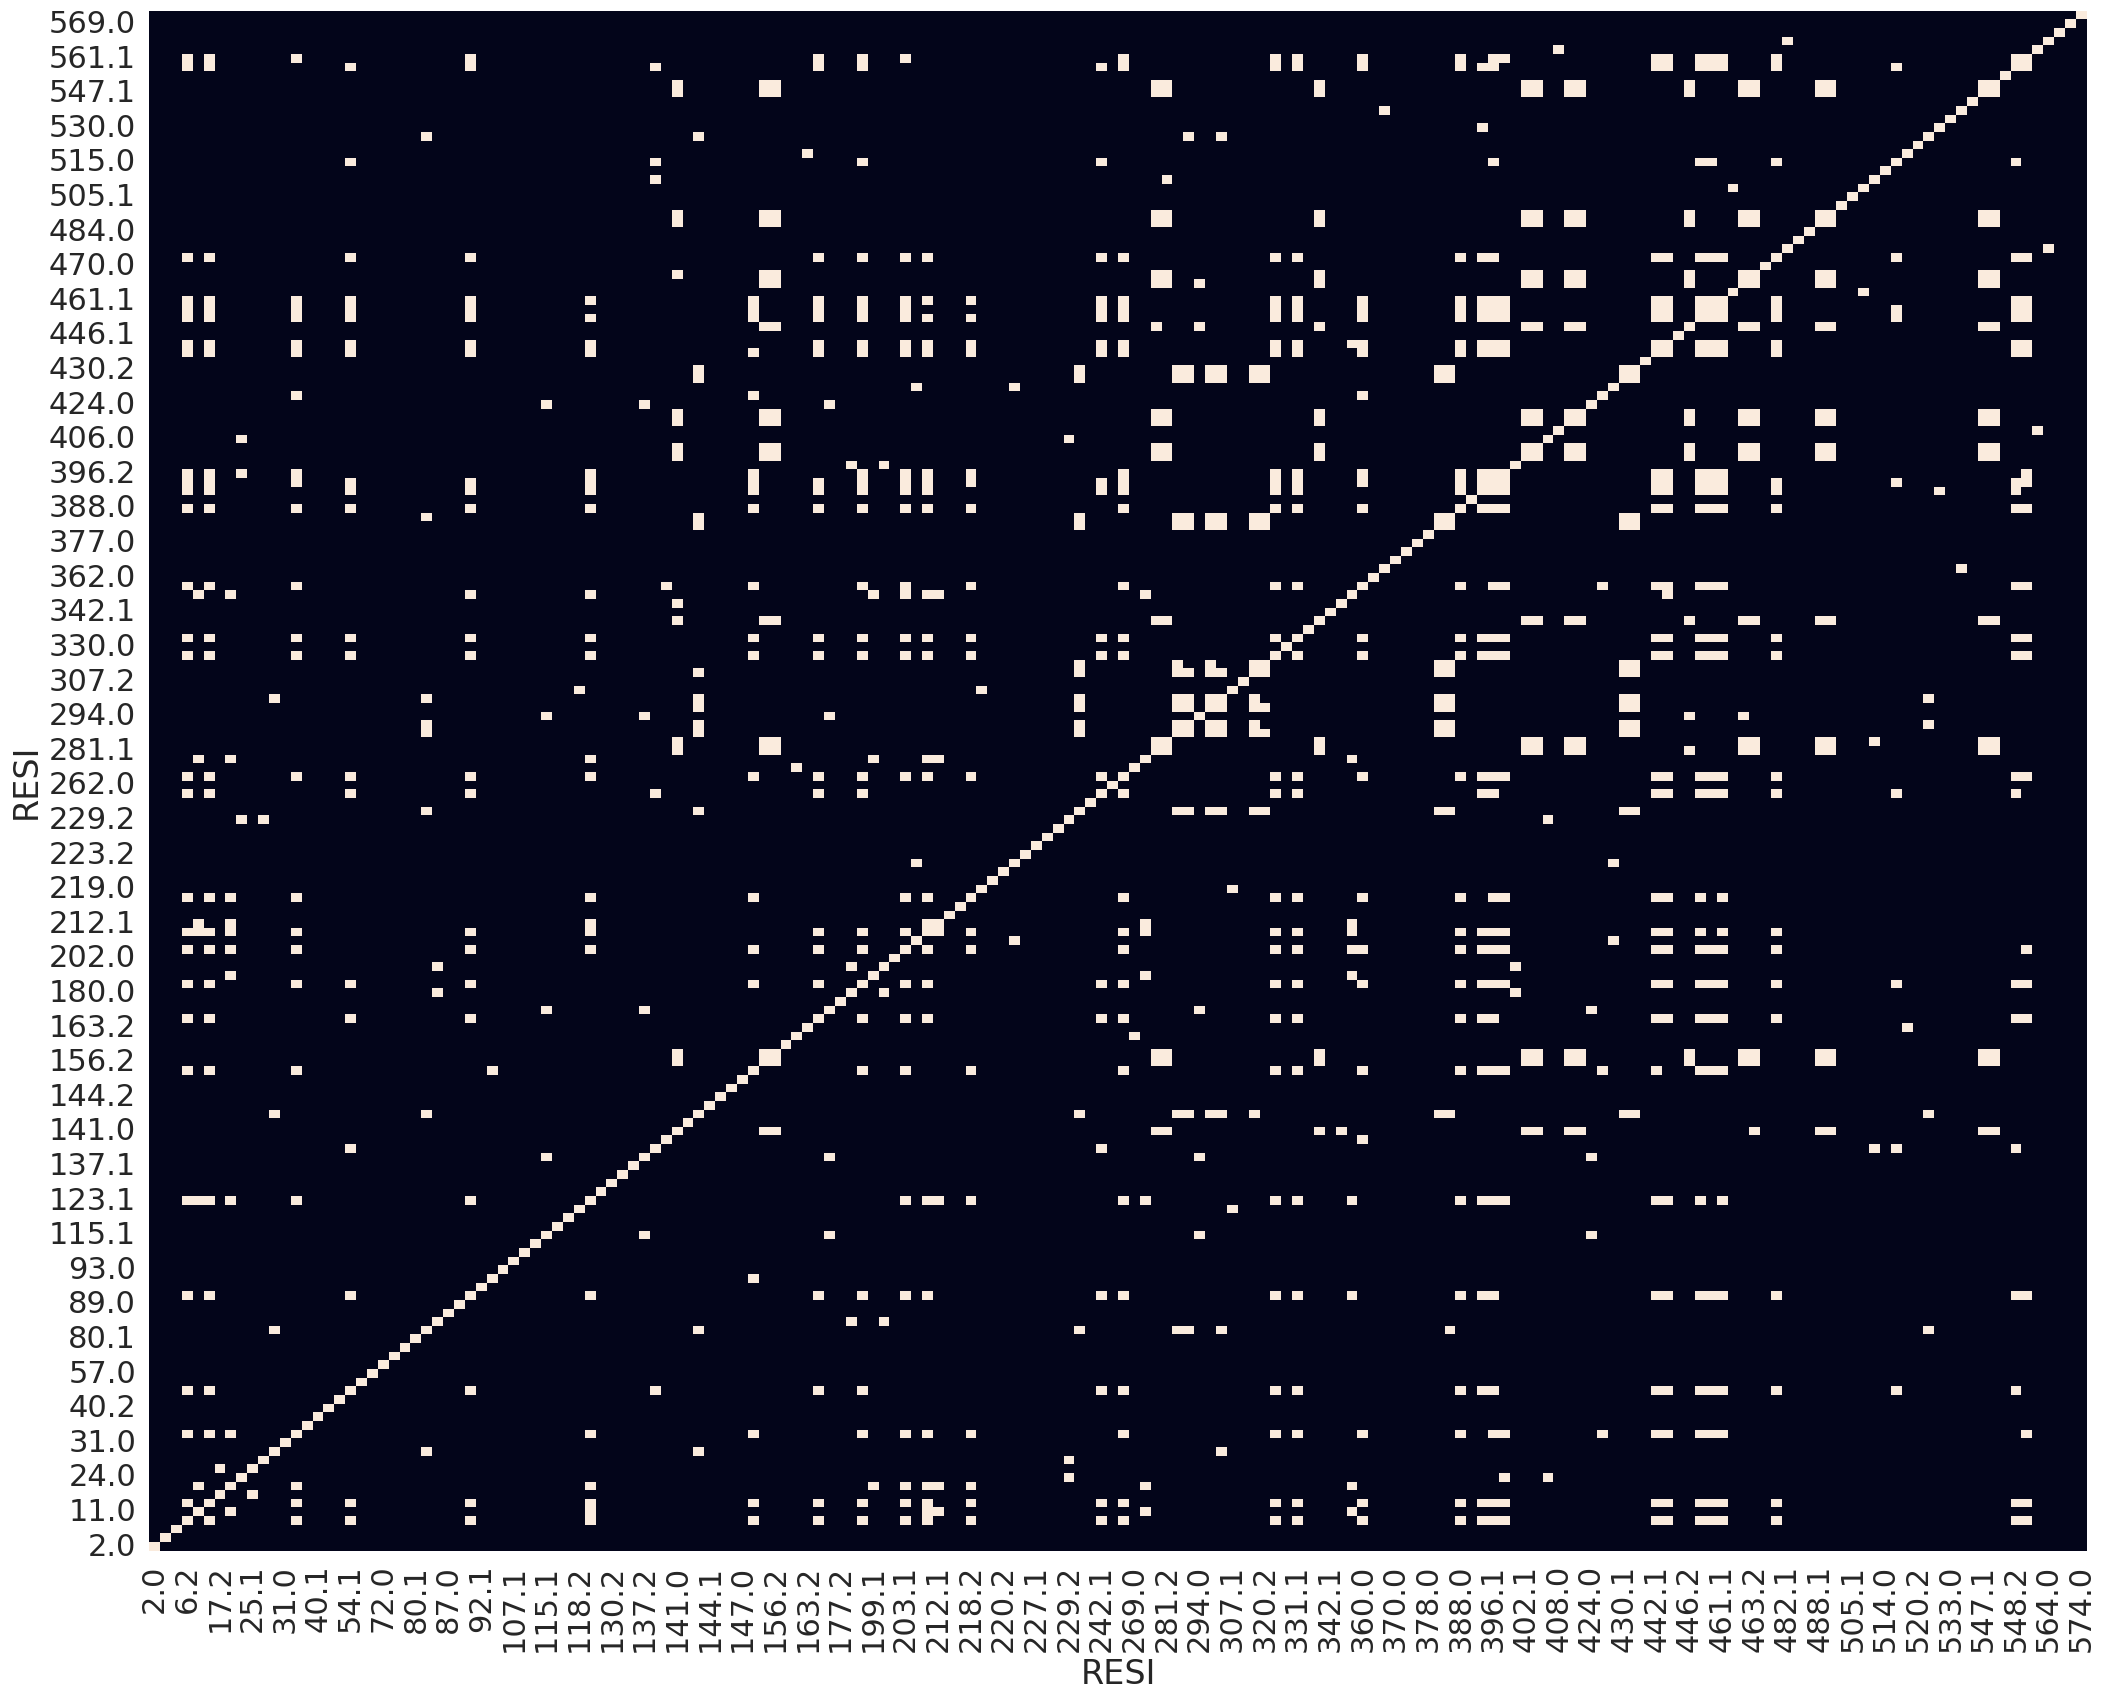

In [10]:
# plot the correlation matrix - the default cutoff is .98
plots.plot_corr(hac)

# get annotation positions

In [6]:
from pychesca.plots import *

IndexError: index 178 is out of bounds for axis 0 with size 178

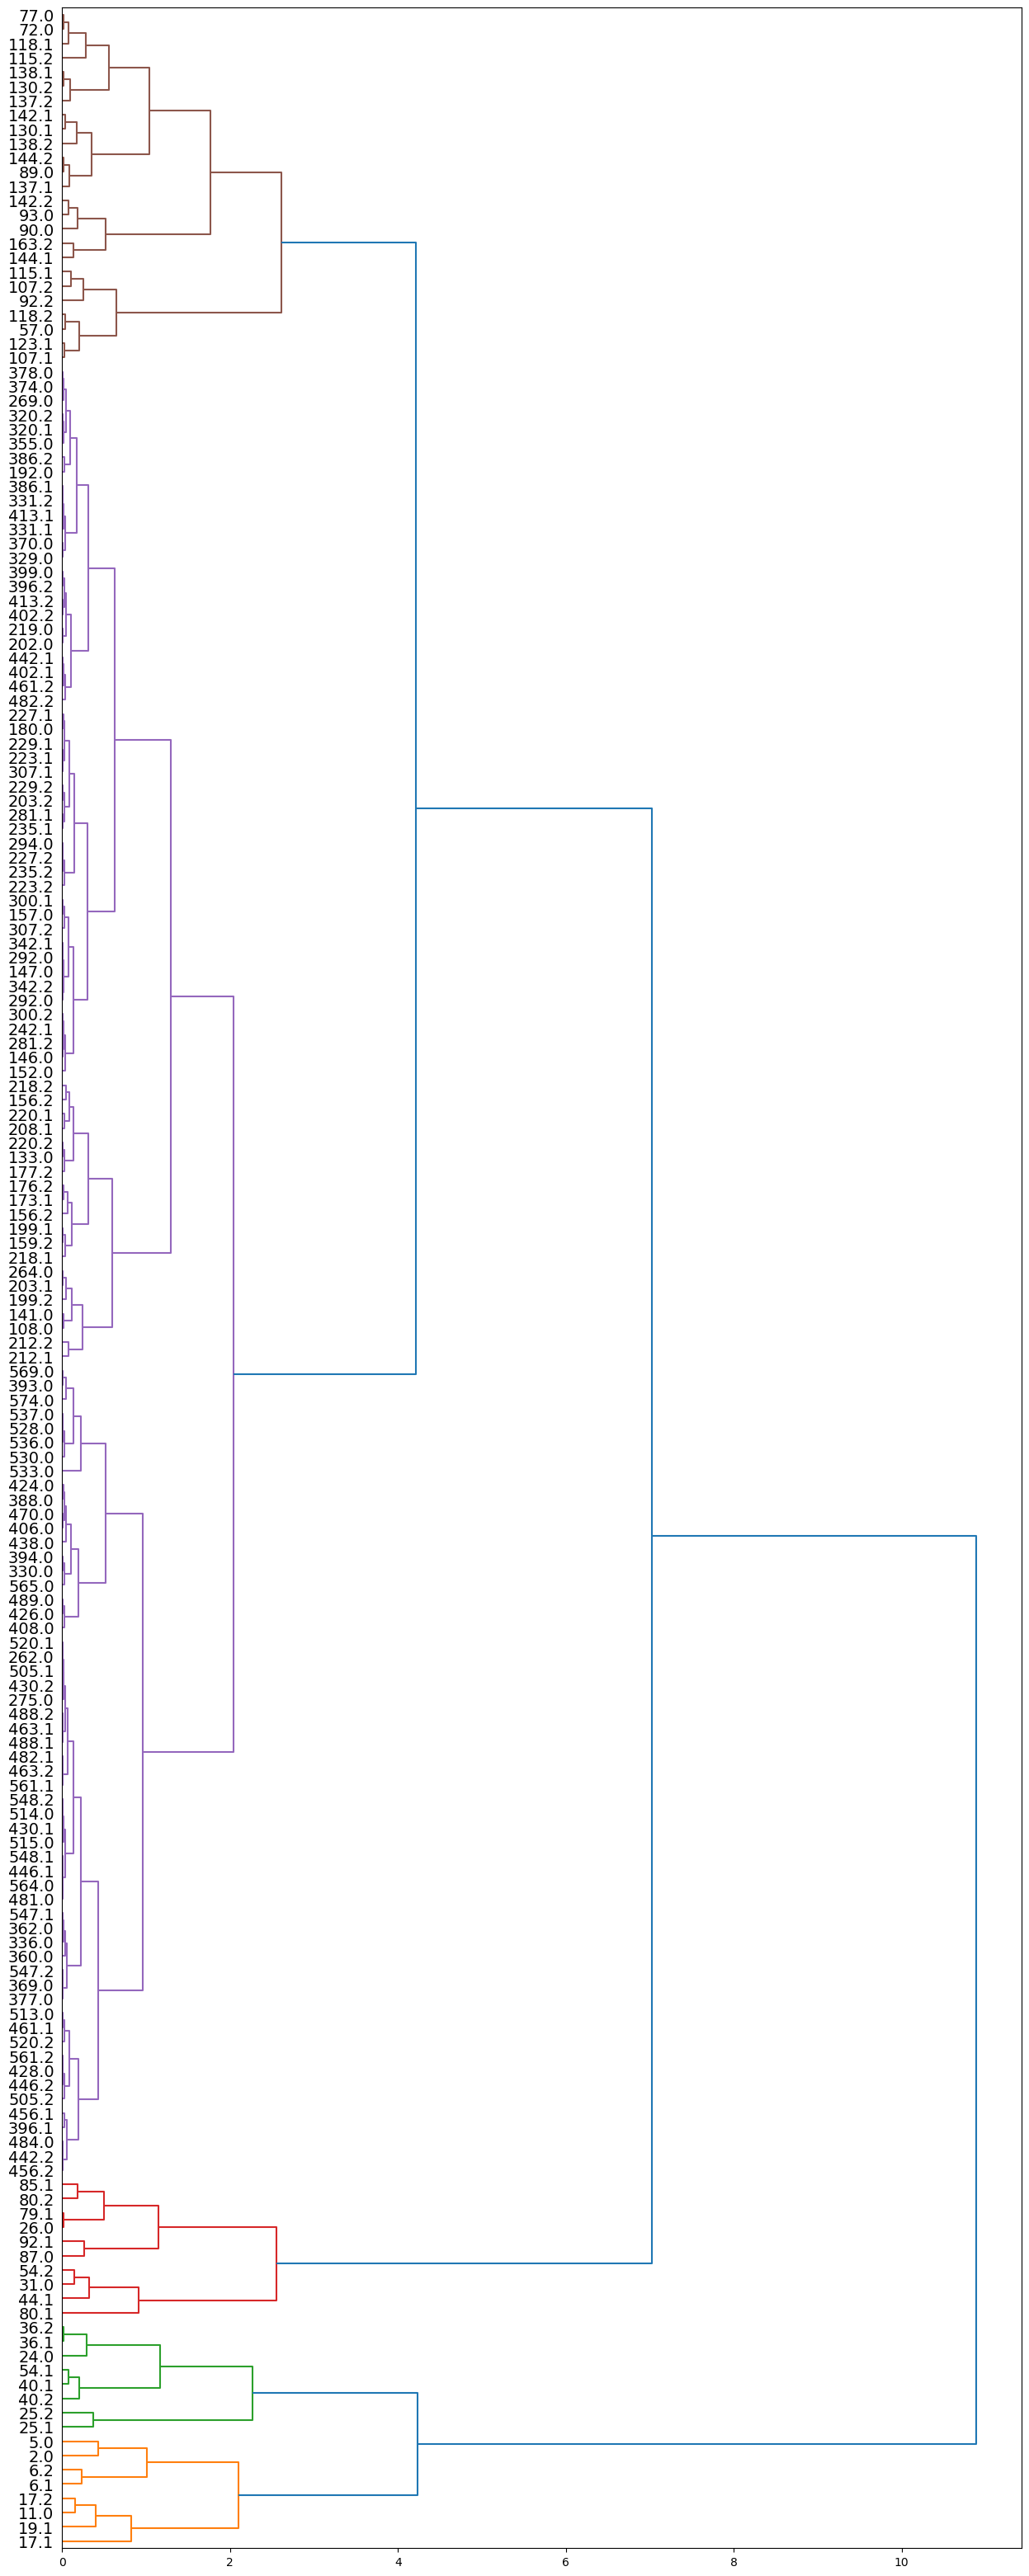

In [ ]:
show_dendrogram(hac)

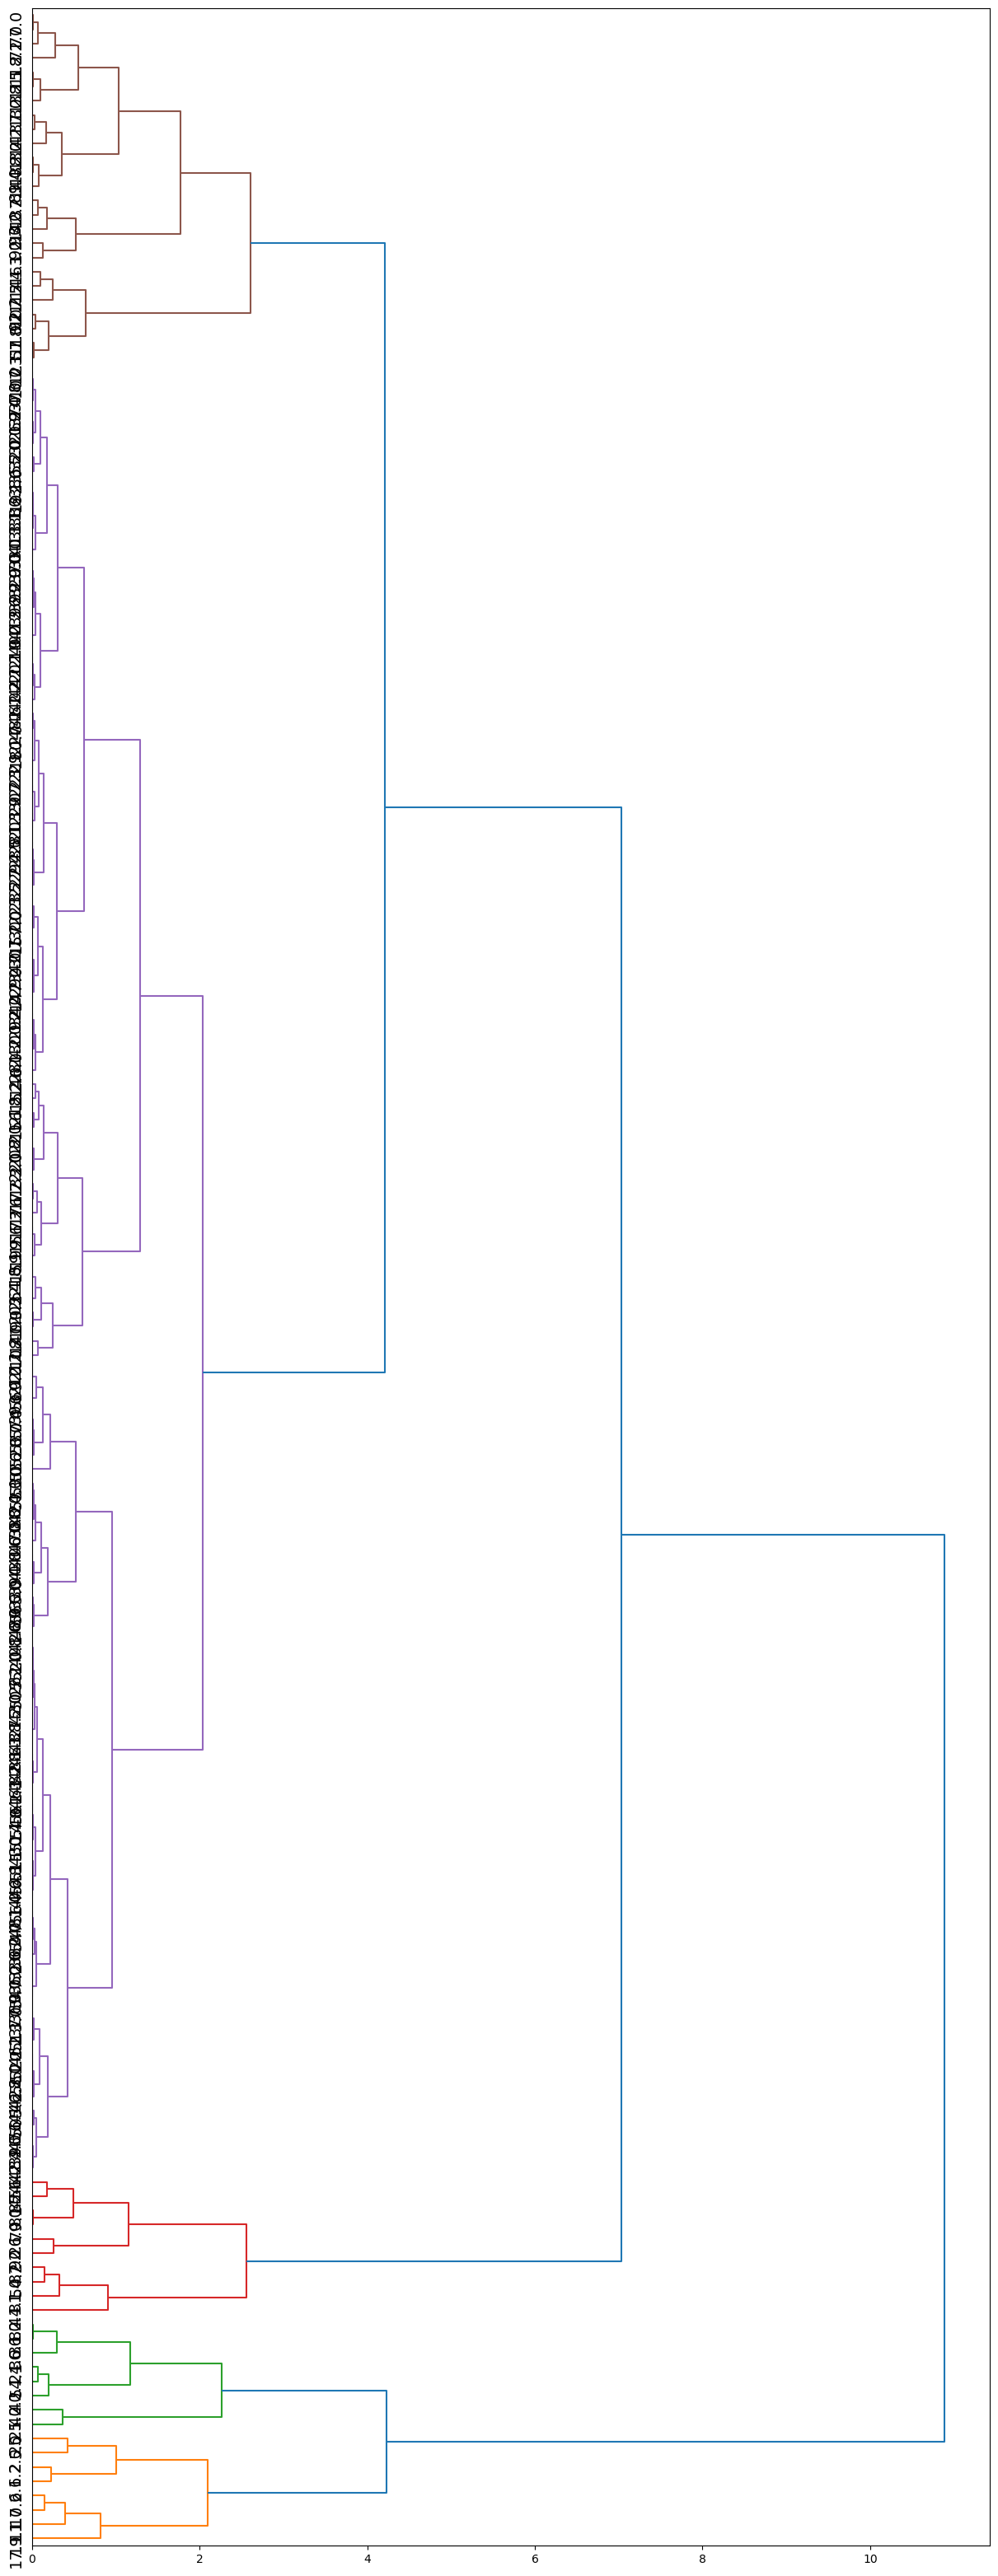

In [9]:
fig, ax = plt.subplots(figsize=(15,40))
kwargs = {'color_threshold':100-hac.cutoff,
              'labels':hac.corr_distance.index,
              'ax':ax,
              'orientation':'right',
              'leaf_rotation':90,
              'leaf_font_size':14
            }
plot_dendrogram(hac.linkage, **kwargs)

In [10]:
clusters = hac.clusters

In [12]:
# get the label value from each text tuple and then order the cluster index according to the order of the ax labels
# the x location values are also much more usefule here - can just extract the middle value of the x positions
# and put the cluster label at that position - then you don't have to track midpoints and so on
orientation = 'right'
ordered_indices = []
x_positions = []
if orientation == 'top':
    for t in ax.get_xticklabels():
        ordered_indices.append(float(t.get_text()))
        x_positions.append(t.get_position())
    x_positions = np.array(x_positions)
else:
    for t in ax.get_yticklabels():
        ordered_indices.append(float(t.get_text()))
        x_positions.append(t.get_position())
    x_positions = np.array(x_positions)

xs = []
for cluster in range(clusters['cluster'].max() + 1):
    # index the x_positions by first putting the clusters df in the same order
    # as the dendrogram and then using the indices to get the x positions for
    # each residue in the cluster (taken from ax.get_xticklabels)
    # and then us the midpoint of these values 
    # the list of values will be in the order that the clusters appear in the dendrogram from
    # left to right
    if orientation == 'top':
        vals = x_positions[np.where(clusters.loc[ordered_indices]['cluster']==cluster)][:,0]
    else:
        vals = x_positions[np.where(clusters.loc[ordered_indices]['cluster']==cluster)][:,1]
    xs.append(np.median(vals))

ys = [threshold] * len(xs)

IndexError: index 178 is out of bounds for axis 0 with size 178

In [18]:
x_positions[np.where(clusters.loc[ordered_indices]['cluster']==2)]

array([[  0, 165],
       [  0, 175],
       [  0, 185],
       [  0, 195],
       [  0, 205],
       [  0, 215],
       [  0, 225],
       [  0, 235],
       [  0, 245],
       [  0, 255]])

In [30]:
check = []

In [31]:
for ind in clusters.index:
    if ind in check:
        print(ind)
    else:
        check.append(ind)

156.2
292.0


In [23]:
clusters.loc[ordered_indices]

,cluster
RESI,
17.1,3
19.1,3
11.0,3
17.2,3
6.1,3
...,...
138.1,0
115.2,0
118.1,0


In [331]:
x_positions[np.where(clusters.loc[ordered_indices]['cluster']==cluster)][:,1]

array([695, 705, 715, 725, 735, 745, 755, 765, 775, 785, 795, 805, 815,
       825, 835, 845, 855, 865, 875, 885, 895, 905, 915, 925, 935])

In [324]:
ax.get_yticklabels()

[Text(0, 5, '44.1'),
 Text(0, 15, '89.0'),
 Text(0, 25, '36.2'),
 Text(0, 35, '79.1'),
 Text(0, 45, '408.0'),
 Text(0, 55, '561.2'),
 Text(0, 65, '107.1'),
 Text(0, 75, '133.0'),
 Text(0, 85, '482.1'),
 Text(0, 95, '564.0'),
 Text(0, 105, '219.0'),
 Text(0, 115, '118.2'),
 Text(0, 125, '307.1'),
 Text(0, 135, '235.1'),
 Text(0, 145, '292.1'),
 Text(0, 155, '386.2'),
 Text(0, 165, '300.2'),
 Text(0, 175, '142.2'),
 Text(0, 185, '292.2'),
 Text(0, 195, '320.2'),
 Text(0, 205, '320.1'),
 Text(0, 215, '386.1'),
 Text(0, 225, '430.2'),
 Text(0, 235, '300.1'),
 Text(0, 245, '430.1'),
 Text(0, 255, '26.0'),
 Text(0, 265, '80.2'),
 Text(0, 275, '528.0'),
 Text(0, 285, '374.0'),
 Text(0, 295, '378.0'),
 Text(0, 305, '142.1'),
 Text(0, 315, '227.1'),
 Text(0, 325, '157.0'),
 Text(0, 335, '484.0'),
 Text(0, 345, '6.1'),
 Text(0, 355, '331.2'),
 Text(0, 365, '377.0'),
 Text(0, 375, '482.2'),
 Text(0, 385, '107.2'),
 Text(0, 395, '533.0'),
 Text(0, 405, '2.0'),
 Text(0, 415, '220.1'),
 Text(0, 425,

In [187]:
hac.clusters.loc[ordered_indices]

,cluster
RESI,
44.1,8
89.0,8
36.2,8
79.1,8
408.0,8
...,...
147.0,14
93.0,7
227.2,7


In [196]:
a = x_positions[np.where(hac.clusters.loc[ordered_indices]['cluster']==8)][:,0]

In [197]:
np.median(a)

40.0

In [ ]:
a.

In [169]:
hac.clusters.iloc[17]

cluster    8
Name: 44.1, dtype: int64

In [117]:
hac.linkage.labels_

array([ 0,  5,  4, 16,  6, 16,  5,  6,  6,  5,  6,  9, 15,  6,  8,  6,  1,
        8, 16, 14, 15,  3, 10,  8, 10,  9,  3,  5,  8, 16, 10, 16,  7,  8,
        0,  1,  1,  7, 10, 12,  6,  0,  2,  8, 13,  1, 16,  6,  0,  9,  9,
       10, 10,  1, 14,  6,  0,  0,  4,  6, 13, 16,  1,  5,  3, 16,  6,  3,
       13,  6, 15,  6,  6, 11,  5,  6, 12,  0,  3, 15,  3,  9,  7, 11,  6,
        9,  2, 16, 11, 16,  6,  6,  0,  0,  9,  9,  2,  9,  9, 12,  1,  9,
        9, 16, 13, 16,  4,  0,  0,  0,  6,  6,  2,  1, 10,  9,  4,  9,  9,
        9, 16, 10, 16, 16,  6,  3,  0,  0,  6,  8,  0,  0,  1,  6, 15,  9,
        9, 11, 16, 16,  6,  2, 16, 16, 16,  3,  2,  0,  3, 16, 12,  0,  4,
        0,  0, 10, 11,  3,  0,  2, 16, 13,  7,  9, 16,  0,  1,  1,  0,  0,
       11, 16, 16,  8, 12,  0,  3, 11])

In [170]:
np.where(hac.clusters['cluster']==8)

(array([ 14,  17,  23,  28,  33,  43, 129, 173]),)

In [103]:
clusters = hac.clusters
threshold = 3

In [115]:
len(np.where(clusters['cluster'] == 0)[0])

25

In [104]:
# Get the x limits of the dendrogram plot
x_min, x_max = ax.get_xlim()
total_width = x_max - x_min

# clusters go from left to right in dendrogram

# track the farthest right x value because it will serve as the first point
# for the next cluster position 
r_pos = 0
xs = []
ys = []
for cluster in range(1, clusters['cluster'].max() + 1):
    # indices of residues that fall in same cluster
    c = np.where((clusters['cluster'] == cluster))[0]  # [0] to unpack tuple
    # size of cluster relative to the total width of the dendrogram
    width = (c.shape[0] / len(clusters.index)) * total_width
    if cluster == 1:
        midpoint = width / 2
        xs.append(midpoint)
        ys.append(threshold)
        r_pos = width
    else:
        midpoint = (width / 2) + r_pos
        xs.append(midpoint)
        ys.append(threshold)
        r_pos += width

In [105]:
lens = []
for cluster in range(1, clusters['cluster'].max() + 1):
    # indices of residues that fall in same cluster
    c = np.where((clusters['cluster'] == cluster))[0]
    lens.append(len(c))

In [106]:
len(lens)

16

In [67]:
from plots import *
get_cluster_annotation_positions(hac.clusters, threshold=2)

([55.0,
  145.0,
  235.0,
  315.0,
  370.0,
  520.0,
  660.0,
  720.0,
  855.0,
  995.0,
  1075.0,
  1135.0,
  1185.0,
  1220.0,
  1255.0,
  1405.0],
 [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [ ]:
# sklearn dendrogram
from scipy.cluster.hierarchy import dendrogram


def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)


iris = load_iris()
X = iris.data

# setting distance_threshold=0 ensures we compute the full tree.
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)

model = model.fit(X)
plt.title("Hierarchical Clustering Dendrogram")
# plot the top three levels of the dendrogram
plot_dendrogram(model, truncate_mode="level", p=3)
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.show()

# SVD

In [9]:
# SVD on the ccs data
dims = svd.SVD(df)

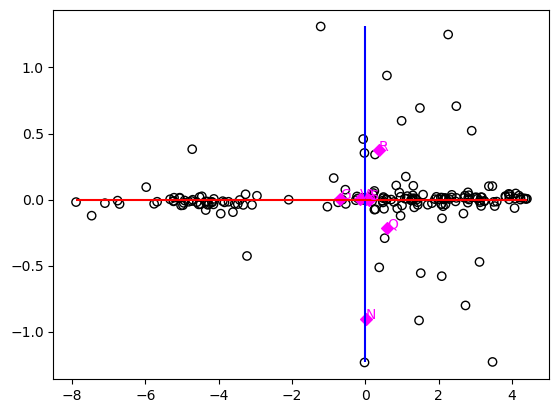

In [10]:
plots.plot_svd(dims)
# need to color the points that are in the subclusters

In [214]:
# ## prep raw cs
# cs = pd.read_csv('test_cs.csv')
# states = ['R','Q','N','A','G','S','V']
# w1 = [f'{state}w1' for state in states]
# w2 = [f'{state}w2' for state in states]
# allws = [a for tup in zip(w1,w2) for a in tup]

# ## mapper.values()to be the A (antagonist), S to be B (agonist), and Q to be ref/apo
# mapper = {'Rw1':'Aw1', 'Rw2':'Aw2', 'Sw1':'Bw1', 'Sw2':'Bw2', 'Qw1':'refw1',
#           'Qw2':'refw2'}
# adjusted = cs[list(mapper.keys())].rename(columns=mapper)
# dat = adjusted[list(mapper.values())]
# dat['RESI'] = df.index
# dat[['RESI', 'Aw1', 'Aw2', 'Bw1', 'Bw2', 'refw1', 'refw2']].to_csv('chespa_cs.csv')


In [217]:
chsp = Chespa('chespa_cs.csv',het_nuc='C')

The index column should be named "RESI".


/home/kanaka/python_packages/pychesca/chespa.py:88: RuntimeWarning: invalid value encountered in divide
  cos_theta = np.nan_to_num(cos_theta, nan=0)


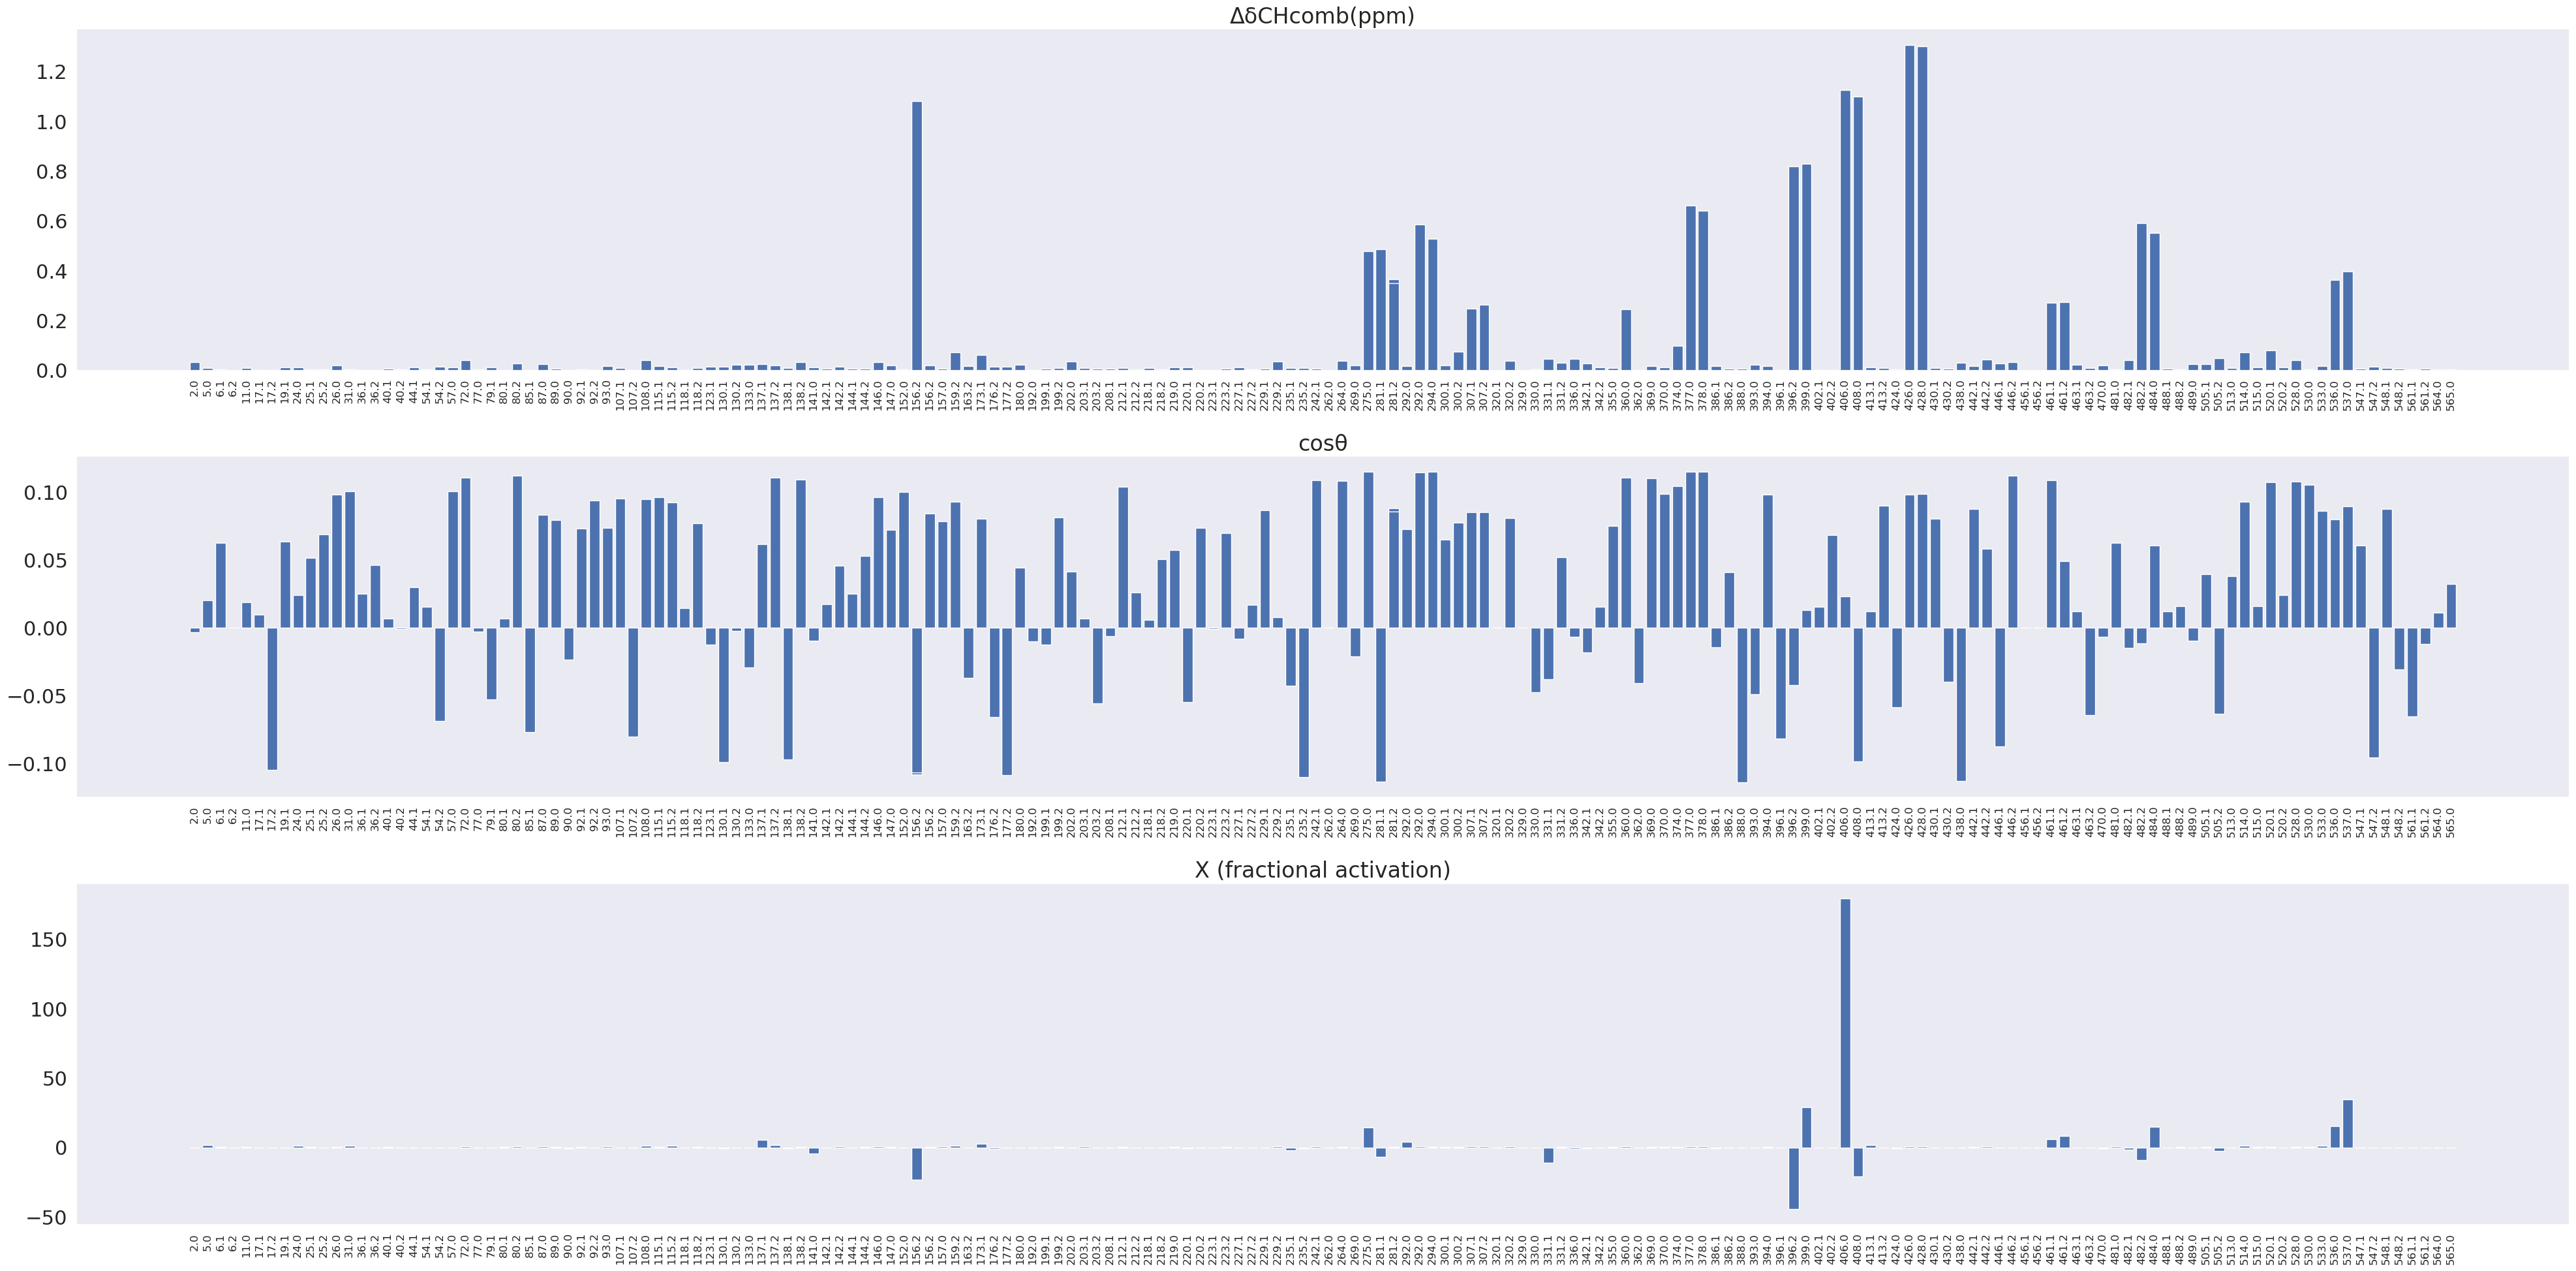

In [221]:
plots.plot_chespa(chsp)

In [239]:
real_clusters = set()
for c_id in hac.clusters['cluster'].unique():
    if len(hac.clusters[hac.clusters['cluster']==c_id])> 6:
        real_clusters.add(c_id)

In [240]:
real_clusters

{1, 3, 5, 6, 7, 8, 9, 11, 12, 13}

In [ ]:
# so now you subcluster each of these
# and then what do you do? - SVD on just those residues' data, project them on 
# the first two components along with the states and determine what the closest
# state is to each residue? I don't think so...
# it looks like a legitimate dendrogram is made with just the states
# I suppose instead of clustering on the matrix transpose correlation, you do it on
# the matrix that gives you just the states for rows and columns - but constructed only 
# with each cluster's residues....

In [10]:
sub_cluster_resis = hac.clusters[hac.clusters['cluster']==21].index
state_corr = df.loc[sub_cluster_resis].corr().abs()
hac_states = cluster.HAC(state_corr, cluster_states=True)

In [11]:
sub_cluster_resis

Index([156.2, 156.2, 281.1, 281.2, 336.0, 402.1, 402.2, 413.1, 413.2, 463.2,
       488.1, 488.2, 547.1, 547.2],
      dtype='float64', name='Resi')

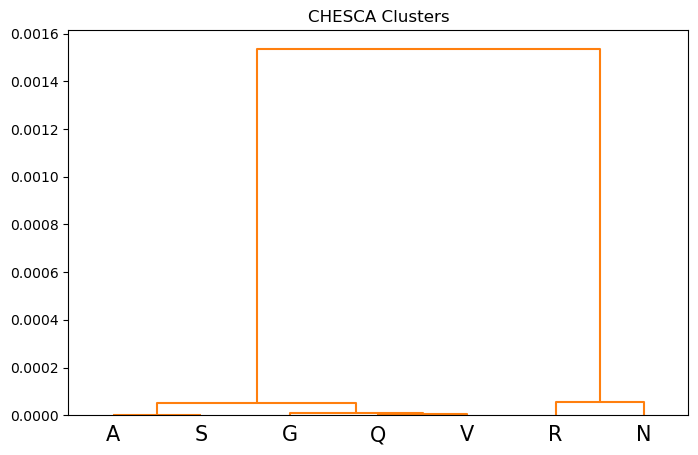

In [12]:
plots.show_dendrogram(hac_states, orientation='top', annotate_clusters=False)
# fix size 
# cluster one seems to separate them correctly.

# small dataset

In [11]:
small = "../../EI_allostery/data/Test_input_smallset.csv"

In [13]:
df = pd.read_csv(small, index_col='RESI')

In [15]:
absolute_corr = df.corr().abs()
corr_distance = 1 - absolute_corr

In [16]:
# perform clustering on the correlation matrix
hac = cluster.HAC(df,cutoff=96)
# look at the absolute values of the correlation matrix
hac.absolute_corr

RESI,32.0,89.0,446.2,142.3,505.3,41.0,17.2,57.1,199.2,528.1,235.3,223.3
RESI,,,,,,,,,,,,
32.0,1.000000,0.980405,0.985267,0.981783,0.979749,0.961079,0.974893,0.977081,0.977081,0.979151,0.982670,0.969662
89.0,0.980405,1.000000,0.998103,0.992505,0.991476,0.980351,0.985014,0.991779,0.991779,0.994921,0.989756,0.989042
446.2,0.985267,0.998103,1.000000,0.993014,0.992502,0.980756,0.985083,0.990951,0.990951,0.993862,0.992995,0.986347
142.3,0.981783,0.992505,0.993014,1.000000,0.993455,0.975925,0.975969,0.980185,0.980185,0.984191,0.982506,0.970795
505.3,0.979749,0.991476,0.992502,0.993455,1.000000,0.986568,0.981697,0.986991,0.986991,0.989324,0.988638,0.974901
41.0,0.961079,0.980351,0.980756,0.975925,0.986568,1.000000,0.994554,0.993510,0.993510,0.992063,0.992896,0.984954
17.2,0.974893,0.985014,0.985083,0.975969,0.981697,0.994554,1.000000,0.998315,0.998315,0.996844,0.996948,0.995048
57.1,0.977081,0.991779,0.990951,0.980185,0.986991,0.993510,0.998315,1.000000,1.000000,0.999622,0.997681,0.997240
199.2,0.977081,0.991779,0.990951,0.980185,0.986991,0.993510,0.998315,1.000000,1.000000,0.999622,0.997681,0.997240


In [20]:
hac.clusters

,cluster
RESI,
32.0,0
89.0,0
446.2,0
142.3,0
505.3,0
41.0,0
17.2,0
57.1,0
199.2,0


In [22]:
sub_cluster_resis = hac.clusters[hac.clusters['cluster']==0].index
state_corr = df.loc[sub_cluster_resis].corr().abs()
hac_states = cluster.HAC(state_corr, cluster_states=True)

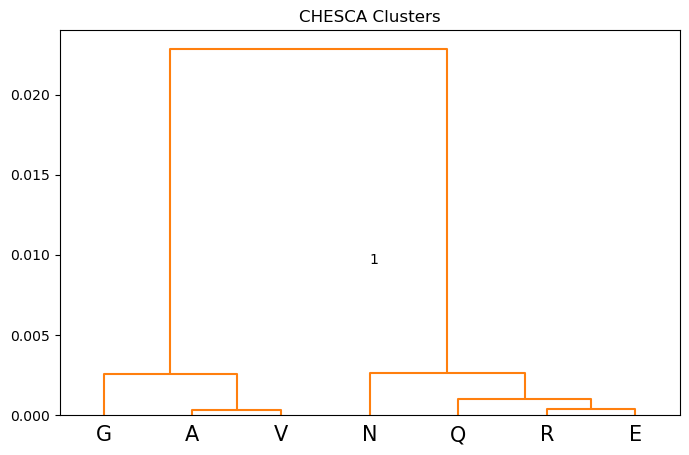

In [28]:
show_dendrogram(hac_states, orientation='top',)# annotate_clusters=False)

In [27]:
hac.corr_distance.max().max()

0.038920730484001576